# Week 1 Seminar

A/B experiment analysis

### Перед анализом провели эксперимент (Random vs StickyArtist)
##### cd botify
##### docker-compose up -d --build --force-recreate --scale recommender=2

#### в отдельном терминале:
##### cd sim
##### source venv-sim/bin/activate #активируем предварительно созданное виртуальное окружение
##### python -m sim.run --episodes 1000 --config config/env.yml single --recommender remote --seed 31337

### Cкопируем логи из контейнеров к себе локально
#### из терминала:
##### cd botify
##### docker cp botify-recommender-1:/app/log/ /tmp/runAB/botify-log-1 
##### docker cp botify-recommender-2:/app/log/ /tmp/runAB/botify-log-2

In [1]:
import glob
from collections import namedtuple

import pandas as pd
import numpy as np
import scipy.stats as ss

import matplotlib.pyplot as plt

pd.set_option("display.precision", 3)

%matplotlib inline

In [2]:
!pip install scipy matplotlib

In [3]:
experiment = "HW"

In [4]:
data = pd.concat([
    pd.read_json(data_path, lines=True)
    for data_path
    in ["/tmp/runAB_HW/botify-log-1/log/data.json", "/tmp/runAB_HW/botify-log-2/log/data.json"]
])

data["treatment"] = data["experiments"].map(lambda experiments: experiments[experiment])

In [5]:
data

,message,timestamp,user,track,time,latency,recommendation,experiments,treatment
0,next,2026-04-29 12:55:37.797,3255,3801,0.06,0.006,5212.0,{'HW': 'C'},C
1,next,2026-04-29 12:55:37.816,3255,11837,0.30,0.003,2454.0,{'HW': 'C'},C
2,next,2026-04-29 12:55:37.832,3255,5128,0.78,0.003,10713.0,{'HW': 'C'},C
3,next,2026-04-29 12:55:37.845,3255,10775,0.75,0.004,10651.0,{'HW': 'C'},C
4,next,2026-04-29 12:55:37.856,3255,11752,0.49,0.002,5222.0,{'HW': 'C'},C
...,...,...,...,...,...,...,...,...,...
6270,next,2026-04-29 12:57:39.412,9165,9911,0.73,0.001,1766.0,{'HW': 'C'},C
6271,next,2026-04-29 12:57:39.431,9165,3955,0.51,0.001,3399.0,{'HW': 'C'},C
6272,next,2026-04-29 12:57:39.445,9165,15642,0.42,0.002,5612.0,{'HW': 'C'},C
6273,next,2026-04-29 12:57:39.454,9165,11228,0.66,0.002,5790.0,{'HW': 'C'},C


In [6]:
data[
    (data["treatment"] == "T1") & 
    (data["user"]== 5020)
].sort_values("timestamp")

,message,timestamp,user,track,time,latency,recommendation,experiments,treatment


In [7]:
data.groupby("treatment").count()

,message,timestamp,user,track,time,latency,recommendation,experiments
treatment,,,,,,,,
C,6034,6034,6034,6034,6034,6034,5534,6034
T1,6515,6515,6515,6515,6515,6515,6015,6515


## Visualize sessions

In [8]:
Session = namedtuple("Session", ["timestamp", "tracks", "time", "latency"])

def sessionize(user_data):
    sessions = []
    session = None
    for _, row in user_data.sort_values("timestamp").iterrows():
        if session is None:
            session = Session(row["timestamp"], 0, 0, 0)
        
        session = session._replace(
            tracks = session.tracks + 1, 
            time = session.time + row["time"],
            latency = session.latency + row["latency"] * 1000,
        )
        
        if row["message"] == "last":
            sessions.append(session._asdict())
            session = None
    return sessions

In [9]:
sessions = (
    data
    .groupby(["user", "treatment"])
    .apply(sessionize)
    .explode()
    .apply(pd.Series)
)

/tmp/ipykernel_12026/2354129256.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(sessionize)


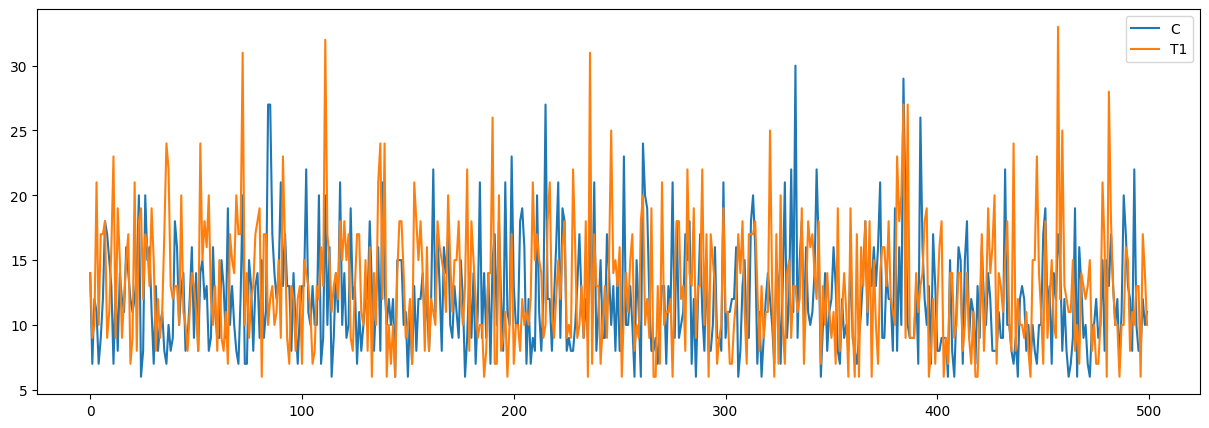

In [10]:
figure, ax = plt.subplots(figsize=(15, 5))
for treatment, treatment_sessions in sessions.groupby("treatment"):
    reindexed_treatment_sessions = treatment_sessions.sort_values("timestamp").reset_index()
    ax.plot(reindexed_treatment_sessions.index, reindexed_treatment_sessions["tracks"], label=treatment)
ax.legend()
pass

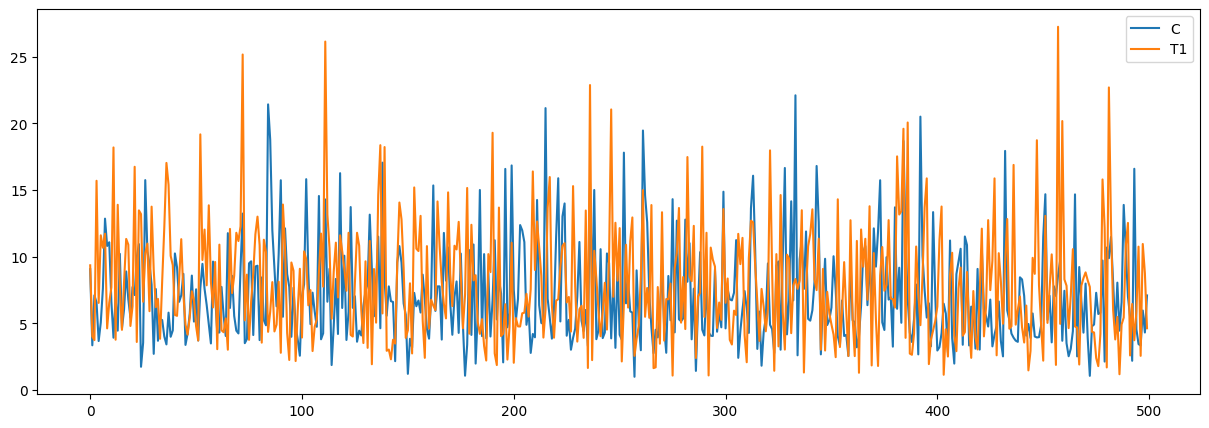

In [11]:
figure, ax = plt.subplots(figsize=(15, 5))
for treatment, treatment_sessions in sessions.groupby("treatment"):
    reindexed_treatment_sessions = treatment_sessions.sort_values("timestamp").reset_index()
    ax.plot(reindexed_treatment_sessions.index, reindexed_treatment_sessions["time"], label=treatment)
ax.legend()
pass

## Analyze the experiment

In [12]:
user_level_data = (
  sessions
    .reset_index()
    .groupby(["user", "treatment"])
    .agg(
        {
            "timestamp": "count",
            "tracks": "sum",
            "time": "sum",
            "latency": "sum"
        }
    )
)

user_level_data["sessions"] = user_level_data["timestamp"]
user_level_data["mean_request_latency"] = user_level_data["latency"] / user_level_data["tracks"]
user_level_data["mean_tracks_per_session"] = user_level_data["tracks"] / user_level_data["sessions"]
user_level_data["mean_time_per_session"] = user_level_data["time"] / user_level_data["sessions"]

metrics = [
    "time", 
    "sessions", 
    "mean_request_latency", 
    "mean_tracks_per_session", 
    "mean_time_per_session"
]

user_level_metrics = user_level_data[metrics].copy().reset_index()

In [13]:
treatment_level_metrics = (
    user_level_metrics
    .groupby("treatment")[metrics]
    .agg(["count", "mean", "var"])
)

In [14]:
def dof(n_0, n_1, s2_0, s2_1):
    numerator = (s2_0 / n_0 + s2_1 / n_1) * (s2_0 / n_0 + s2_1 / n_1)
    denominator = s2_0 * s2_0 / n_0 / n_0 / (n_0 - 1) + s2_1 * s2_1 / n_1 / n_1 / (n_1 - 1)
    return numerator / denominator


def ci(n_0, n_1, s2_0, s2_1, alpha=0.05):
    return ss.t.ppf(1 - alpha/2, dof(n_0, n_1, s2_0, s2_1)) * np.sqrt(s2_0 / n_0 + s2_1 / n_1)


effects = []

control = [data for treatment, data in treatment_level_metrics.iterrows() if treatment == "C"][0]

for treatment, row in treatment_level_metrics.iterrows():
    if treatment == "C":
        continue
    
    for metric in metrics:
        control_mean = control[metric]["mean"]
        treatment_mean = row[metric]["mean"]
        
        effect = treatment_mean - control_mean
        conf_int = ci(
            control[metric]["count"],
            row[metric]["count"],
            control[metric]["var"],
            row[metric]["var"],
        )
        effects.append({
            "treatment": treatment,
            "metric": metric,
            "control_mean": control_mean,
            "treatment_mean": treatment_mean,
            "effect": effect / control_mean * 100,
            "lower": (effect - conf_int) / control_mean * 100,
            "upper": (effect + conf_int) / control_mean * 100,
            "significant": (effect + conf_int) * (effect - conf_int) > 0
        })

In [15]:
def color(value):
    return 'color:red;' if value < 0 else 'color:green;'

def background(value):
    return 'color:white;background-color:green' if value else 'color:white;background-color:red'
        

(
    pd.DataFrame(effects)[[
        "treatment", 
        "metric",
        "effect", 
        "upper", 
        "lower", 
        "control_mean", 
        "treatment_mean",
        "significant"
    ]]
    .sort_values(["metric", "treatment"], ascending=False)
    .style
    .map(color, subset=["effect", "upper", "lower"])
    .map(background, subset=["significant"])
)

,treatment,metric,effect,upper,lower,control_mean,treatment_mean,significant
0,T1,time,10.869009,18.735494,3.002523,7.626298,8.455201,True
1,T1,sessions,-0.634249,2.232208,-3.500707,1.063830,1.057082,False
3,T1,mean_tracks_per_session,7.791476,12.580626,3.002326,12.069149,13.009514,True
4,T1,mean_time_per_session,11.472041,18.763762,4.180321,7.170979,7.993636,True
2,T1,mean_request_latency,-1.613496,1.690994,-4.917987,2.205102,2.169522,False


In [17]:
# Посчитаем среднее количество повторов трека на пользователя
def count_repeats_for_user(df_user):
    seen = set()
    repeats = 0
    for t in df_user["track"]:
        if t in seen:
            repeats += 1
        else:
            seen.add(t)
    return repeats


data_next = (
    data[(data["message"] == "next")&(data["treatment"]== "T1" )]
    .sort_values(["user", "timestamp"])
)


repeats_per_user = data_next.groupby("user").apply(count_repeats_for_user)


mean_repeats = repeats_per_user.mean()
mean_repeats

/tmp/ipykernel_9146/3550609387.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  repeats_per_user = data_next.groupby("user").apply(count_repeats_for_user)


0.8435517970401691